# RAVDESS and Actor 25 label analysis

This notebook counts emotion and gender labels from the seven-part RAVDESS filename convention. It compares RAVDESS only, Actor 25 only, and the combined set, then plots emotion and gender balance.

Place `Audio_Speech_Actors_01-24.zip` under `data/` and unzip it to `data/RAVDESS/`. Place the 60 Actor 25 recordings under `data/Actor_25/`. The notebook also recognizes the `work/` paths used during preparation.

In [1]:
from collections import Counter, defaultdict
from pathlib import Path
import wave
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, Image

EMOTIONS = {
    "01": "neutral", "02": "calm", "03": "happy", "04": "sad",
    "05": "angry", "06": "fearful", "07": "disgust", "08": "surprised",
}
EMOTION_ORDER = list(EMOTIONS.values())
ACTOR_25_GENDER = "Male"  # selected for the added speaker

def find_folder(candidates, label):
    for candidate in candidates:
        if candidate.is_dir():
            return candidate
    raise FileNotFoundError(f"'{label}' folder not found. Place it in data/ as described above.")

RAVDESS_DIR = find_folder([Path("data/RAVDESS"), Path("work/RAVDESS"), Path("RAVDESS")], "RAVDESS")
ACTOR_25_DIR = find_folder([Path("data/Actor_25"), Path("work/Actor_25"), Path("Actor_25")], "Actor_25")
print("RAVDESS folder:", RAVDESS_DIR)
print("Actor 25 folder:", ACTOR_25_DIR)

RAVDESS folder: data/RAVDESS
Actor 25 folder: data/Actor_25


In [2]:
def read_labels(folder, dataset):
    rows = []
    invalid = []
    for path in sorted(folder.rglob("*.wav")):
        fields = path.stem.split("-")
        if len(fields) != 7 or fields[0] != "03" or fields[1] != "01":
            invalid.append(path.name)
            continue
        _, _, emotion_code, intensity, statement, repetition, actor_code = fields
        actor = int(actor_code)
        gender = ACTOR_25_GENDER if actor == 25 else ("Male" if actor % 2 else "Female")
        rows.append({
            "file": path.name, "dataset": dataset, "emotion": EMOTIONS.get(emotion_code, "unknown"),
            "emotion_code": emotion_code, "intensity": intensity, "statement": statement,
            "repetition": repetition, "actor": actor, "gender": gender,
        })
    if invalid:
        raise ValueError(f"Unexpected filenames (first five): {invalid[:5]}")
    return rows

ravdess = read_labels(RAVDESS_DIR, "RAVDESS")
actor25 = read_labels(ACTOR_25_DIR, "Actor 25")
combined = ravdess + actor25
datasets = {"RAVDESS only": ravdess, "Actor 25 only": actor25, "Combined": combined}

for name, rows in datasets.items():
    emotion_counts = Counter(row["emotion"] for row in rows)
    gender_counts = Counter(row["gender"] for row in rows)
    print(f"\n{name}: {len(rows)} recordings")
    print("Emotion counts:", {emotion: emotion_counts[emotion] for emotion in EMOTION_ORDER})
    print("Gender counts:", dict(gender_counts))

gender_by_emotion = defaultdict(Counter)
for row in combined:
    gender_by_emotion[row["emotion"]][row["gender"]] += 1
print("\nCombined emotion by gender")
for emotion in EMOTION_ORDER:
    print(f"{emotion:10} Male={gender_by_emotion[emotion]['Male']:3} Female={gender_by_emotion[emotion]['Female']:3}")

# Check the file container on one Actor 25 recording. Label counts above use filenames.
sample_voice_file = next(ACTOR_25_DIR.rglob("*.wav"))
try:
    with wave.open(str(sample_voice_file), "rb") as wav:
        print(f"\nActor 25 audio check: PCM WAV, {wav.getframerate()} Hz, {wav.getnchannels()} channel(s)")
except wave.Error:
    print("\nWARNING: Actor 25 files have .wav names but are not PCM WAV containers. Filename label counts are valid; convert before audio feature extraction or sharing.")


RAVDESS only: 1440 recordings
Emotion counts: {'neutral': 96, 'calm': 192, 'happy': 192, 'sad': 192, 'angry': 192, 'fearful': 192, 'disgust': 192, 'surprised': 192}
Gender counts: {'Male': 720, 'Female': 720}

Actor 25 only: 60 recordings
Emotion counts: {'neutral': 4, 'calm': 8, 'happy': 8, 'sad': 8, 'angry': 8, 'fearful': 8, 'disgust': 8, 'surprised': 8}
Gender counts: {'Male': 60}

Combined: 1500 recordings
Emotion counts: {'neutral': 100, 'calm': 200, 'happy': 200, 'sad': 200, 'angry': 200, 'fearful': 200, 'disgust': 200, 'surprised': 200}
Gender counts: {'Male': 780, 'Female': 720}

Combined emotion by gender
neutral    Male= 52 Female= 48
calm       Male=104 Female= 96
happy      Male=104 Female= 96
sad        Male=104 Female= 96
angry      Male=104 Female= 96
fearful    Male=104 Female= 96
disgust    Male=104 Female= 96
surprised  Male=104 Female= 96

Actor 25 audio check: PCM WAV, 48000 Hz, 1 channel(s)


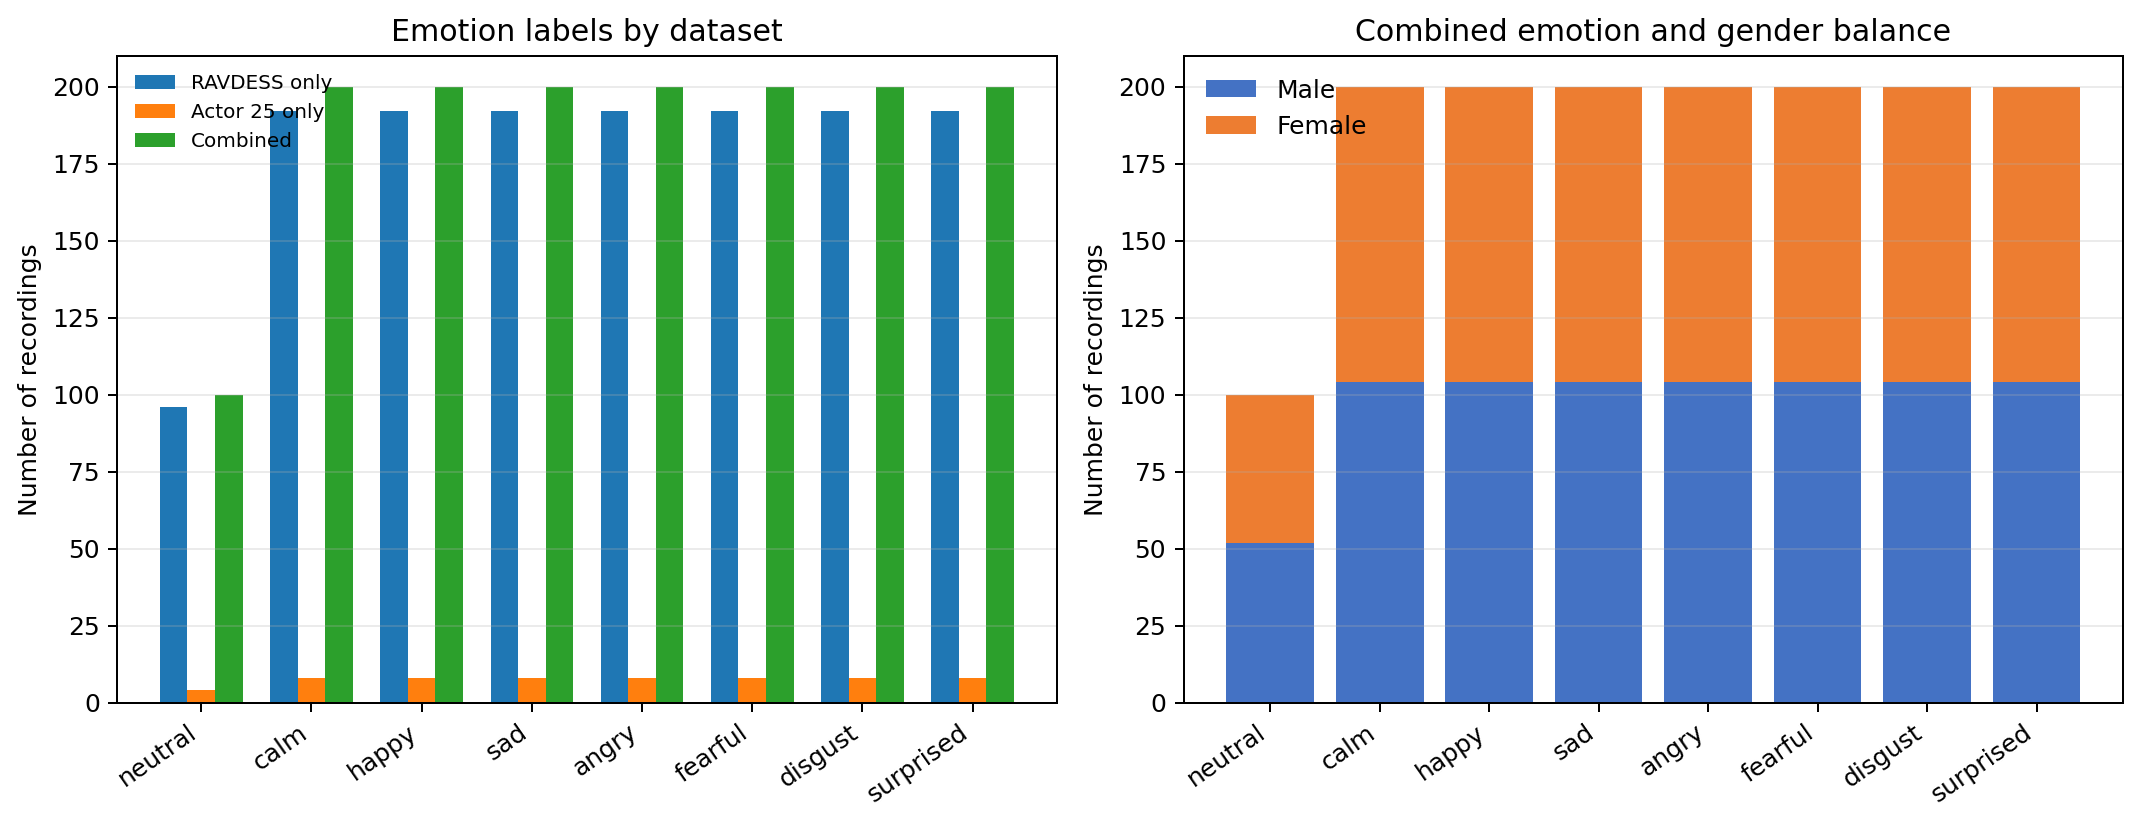

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.7))
x = np.arange(len(EMOTION_ORDER))
width = 0.25
for index, (name, rows) in enumerate(datasets.items()):
    counts = Counter(row["emotion"] for row in rows)
    axes[0].bar(x + (index - 1) * width, [counts[e] for e in EMOTION_ORDER], width, label=name)
axes[0].set_title("Emotion labels by dataset")
axes[0].set_ylabel("Number of recordings")
axes[0].set_xticks(x, EMOTION_ORDER, rotation=35, ha="right")
axes[0].legend(frameon=False, fontsize=8)
axes[0].grid(axis="y", alpha=0.25)

male = [gender_by_emotion[e]["Male"] for e in EMOTION_ORDER]
female = [gender_by_emotion[e]["Female"] for e in EMOTION_ORDER]
axes[1].bar(x, male, label="Male", color="#4472C4")
axes[1].bar(x, female, bottom=male, label="Female", color="#ED7D31")
axes[1].set_title("Combined emotion and gender balance")
axes[1].set_ylabel("Number of recordings")
axes[1].set_xticks(x, EMOTION_ORDER, rotation=35, ha="right")
axes[1].legend(frameon=False)
axes[1].grid(axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig("label_balance.png", dpi=180, bbox_inches="tight")
display(Image(filename="label_balance.png"))
plt.close(fig)

## Notes for the report

RAVDESS has 24 actors and 1,440 audio-speech recordings. Actor 25 contributes 60 recordings, using the same two statements and emotion/intensity/repetition code structure. The combined set has 1,500 recordings. Neutral has half as many examples as each other emotion in the RAVDESS design.

Actor 25 is one male speaker, so the combined counts are 780 male and 720 female recordings (52% and 48%). RAVDESS represents many professional speakers, while the added data represents one self-recorded speaker. Counts are filename labels only; they do not assess whether the spoken emotion is perceptually accurate.